In [ ]:




# Step 4:




# Step 5:


# Calculating IQR and Z-Score
# Step 6:

# Train_Test_Split
# Step 7:

# Scaler_Transform
# Step 8:

# Build Model
# Step 9:
# Training the Model

# Step 10:
# Predicting / Evaluating the Model

# Step 11:
# Checking the Model Accuracy

# Step 12: 
# Validation

 # **Aim:-**

##### **Performing EDA on a liver disease dataset that can classify liver disease types (Hepatitis, Fibrosis, Cirrhosis) based on patients’ demographic details and biochemical test results, in order to assist in early detection, diagnosis, and better clinical decision-making.**


In [19]:
# **Loading the DataSet**
import pandas as pd

df= pd.read_csv(r"C:\Users\aryan\OneDrive\Desktop\AI Summer Training\DataSets\Hcv_project_data.csv")

df

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,811,1=Hepatitis,41,m,47.2,52.2,79.5,175.2,22.5,11.30,5.90,83.0,103.2,80.2
811,812,2=Fibrosis,53,f,37.9,NaN,113.2,175.2,10.9,7.90,3.70,72.0,163.2,74.2
812,813,3=Cirrhosis,57,m,28.2,129.2,44.5,223.2,103.2,2.60,3.10,111.0,377.2,60.2
813,814,1=Hepatitis,33,f,43.9,41.9,67.2,140.2,18.8,10.20,6.00,72.0,85.2,77.2


# **Data Information Gathering**


In [20]:
## Checking Null Values
print("Null Values in the dataset:- \n",df.isnull().sum())


Null Values in the dataset:- 
 Unnamed: 0     0
Category       0
Age            0
Sex            0
ALB            1
ALP           51
ALT            1
AST            0
BIL            0
CHE            0
CHOL          22
CREA           0
GGT            0
PROT           1
dtype: int64


In [21]:
##Checking Duplicates 
print("Duplicates in the dataset:-",df.duplicated().sum())

Duplicates in the dataset:- 0


In [22]:
## Checking the datatype 

df.dtypes

Unnamed: 0      int64
Category       object
Age             int64
Sex            object
ALB           float64
ALP           float64
ALT           float64
AST           float64
BIL           float64
CHE           float64
CHOL          float64
CREA          float64
GGT           float64
PROT          float64
dtype: object

In [23]:
##checking the skewness
print(f"ALB skewness: {df['ALB'].skew()}\n"
      f"ALP skewness: {df['ALP'].skew()}\n"
      f"ALT skewness: {df['ALT'].skew()}\n"
      f"AST skewness: {df['AST'].skew()}\n"
      f"BIL skewness: {df['BIL'].skew()}\n"
      f"CHE skewness: {df['CHE'].skew()}\n"
      f"CHOL skewness: {df['CHOL'].skew()}\n"
      f"CREA skewness: {df['CREA'].skew()}\n"
      f"GGT skewness: {df['GGT'].skew()}\n"
      f"PROT skewness: {df['PROT'].skew()}\n"
)


ALB skewness: -0.43963104443653056
ALP skewness: 3.0698367646171256
ALT skewness: 2.5595007826297875
AST skewness: 1.3758122403416793
BIL skewness: 3.689459137620992
CHE skewness: -0.37543168420598005
CHOL skewness: 0.2693213450622553
CREA skewness: 16.24237787754209
GGT skewness: 2.3754408106684526
PROT skewness: -1.00674973095623



### Interpretation of Each Feature’s Skewness

ALB: -0.44 → Slightly left-skewed, but close to normal.

ALP: 3.07 → Highly right-skewed, long tail on right.

ALT: 2.56 → Highly right-skewed.

AST: 1.37 → Moderately right-skewed.

BIL: 3.68 → Highly right-skewed.

CHE: -0.37 → Almost symmetric, tiny left skew.

CHOL: 0.27 → Very close to normal, slight right skew.

CREA: 16.24  → Extremely right-skewed (lots of outliers).

GGT: 2.38 → Highly right-skewed.

PROT: -1.00 → Moderately left-skewed.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  815 non-null    int64  
 1   Category    815 non-null    object 
 2   Age         815 non-null    int64  
 3   Sex         815 non-null    object 
 4   ALB         814 non-null    float64
 5   ALP         764 non-null    float64
 6   ALT         814 non-null    float64
 7   AST         815 non-null    float64
 8   BIL         815 non-null    float64
 9   CHE         815 non-null    float64
 10  CHOL        793 non-null    float64
 11  CREA        815 non-null    float64
 12  GGT         815 non-null    float64
 13  PROT        814 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 89.3+ KB


In [25]:
df.describe()

,Unnamed: 0,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,815.000000,815.000000,814.000000,764.000000,814.000000,815.000000,815.000000,815.000000,793.000000,815.000000,815.000000,814.000000
mean,408.000000,48.414724,40.792015,69.224215,38.346069,67.702945,18.795337,8.012675,5.153594,82.109202,76.503067,71.879607
std,235.414528,10.755253,6.441883,28.884029,32.013080,67.950547,29.319858,2.517787,1.190171,44.231943,98.201001,6.510136
min,1.000000,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.400000,1.430000,8.000000,4.500000,44.800000
25%,204.500000,40.000000,37.800000,50.175000,18.225000,23.000000,5.900000,6.740000,4.350000,68.000000,18.200000,68.925000
50%,408.000000,48.000000,41.500000,64.450000,27.200000,30.000000,9.200000,8.290000,5.100000,78.000000,30.700000,72.250000
75%,611.500000,56.000000,45.000000,82.625000,47.400000,118.250000,16.550000,9.685000,5.930000,89.550000,93.450000,76.100000
max,815.000000,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


# **Data Cleaning**


In [26]:
## Droping Unnecessary Column

df.drop(columns='Unnamed: 0', inplace=True)

In [27]:
df

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,1=Hepatitis,41,m,47.2,52.2,79.5,175.2,22.5,11.30,5.90,83.0,103.2,80.2
811,2=Fibrosis,53,f,37.9,NaN,113.2,175.2,10.9,7.90,3.70,72.0,163.2,74.2
812,3=Cirrhosis,57,m,28.2,129.2,44.5,223.2,103.2,2.60,3.10,111.0,377.2,60.2
813,1=Hepatitis,33,f,43.9,41.9,67.2,140.2,18.8,10.20,6.00,72.0,85.2,77.2


In [ ]:
## Filling Null Values by finding out the median values

df['ALB'] = df['ALB'].fillna(df['ALB'].median())
df['ALP'] = df['ALP'].fillna(df['ALP'].median())
df['CHOL'] = df['CHOL'].fillna(df['CHOL'].median())
df['PROT'] = df['PROT'].fillna(df['PROT'].median())
df['ALT'] = df['ALT'].fillna(df['ALT'].median())



In [36]:
df.isnull().sum()


Category    0
Age         0
Sex         0
ALB         0
ALP         0
ALT         0
AST         0
BIL         0
CHE         0
CHOL        0
CREA        0
GGT         0
PROT        0
dtype: int64

# **Feature Engineering**

In [60]:
## Importing LabelEncoder for converting Categorical column such as "Category" to numerical form for easy analysis 

from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

df['Category']=encoder.fit_transform(df['Category'])
df['Sex']=encoder.fit_transform(df['Sex'])

# **Data Visulaization**

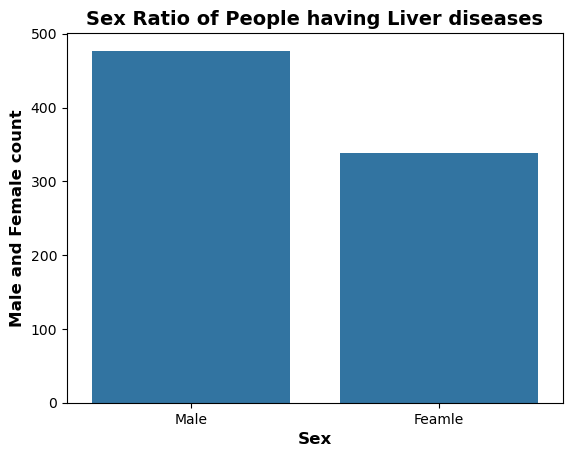

In [59]:
## Importing Seaborn and matplotib library for advanced visulaization
import seaborn as sns
import matplotlib.pyplot as plt

## CountPlot for determining  Sex

sns.countplot(x="Sex", data=df)
plt.title("Sex Ratio of People having Liver diseases",fontweight='bold', fontsize=14 )
plt.xlabel("Sex",fontweight='bold', fontsize=12 )
plt.ylabel("Male and Female count",fontweight='bold', fontsize=12 )
plt.xticks([0, 1], ["Male", "Feamle"])
plt.show()




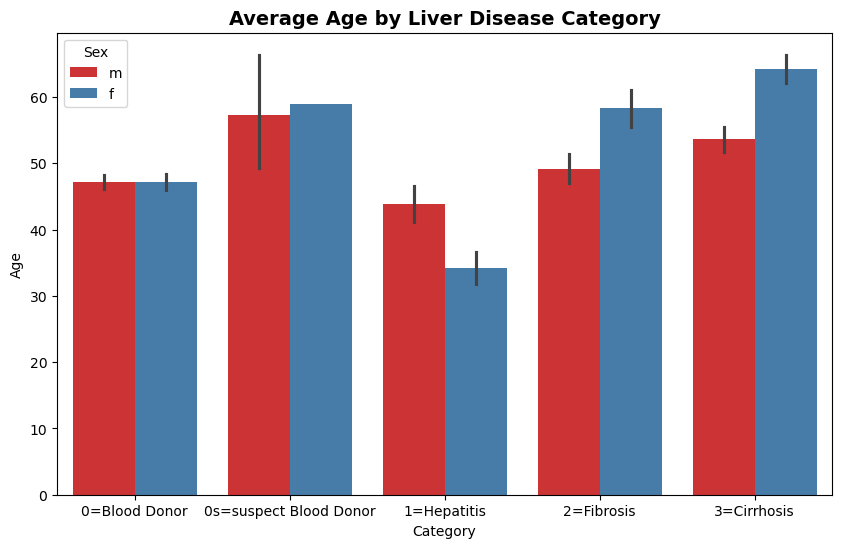

In [56]:
## Bar chart representing the liver diseases respect to the ages 

import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="Category", y="Age", data=df,hue='Sex', estimator="mean", palette="Set1")
plt.title("Average Age by Liver Disease Category", fontsize=14, fontweight="bold")
plt.show()


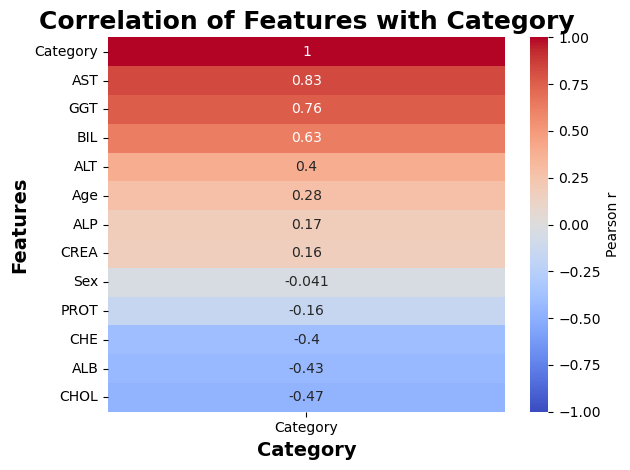

In [ ]:
## Heatmap for finding the correlation of all the features with respect to the liver diseases

sns.heatmap(
    df.corr(numeric_only=True)[['Category']].sort_values('Category', ascending=False),
    annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label':'Pearson r'}
)
plt.title("Correlation of Features with Category",fontsize=18, fontweight="bold")
plt.xlabel("Category",fontsize=14, fontweight="bold")
plt.ylabel("Features",fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


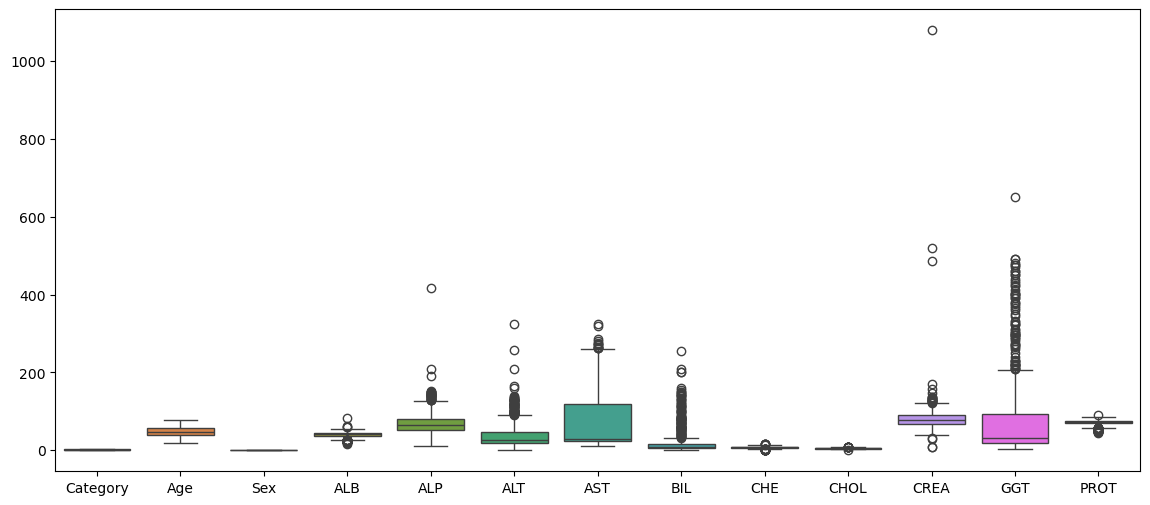

In [76]:
## Boxplot for determining the outliers visually 

plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.show()



In [ ]:
### Interpretation of Each Feature’s Skewness

ALB: -0.44 → Slightly left-skewed, but close to normal.

ALP: 3.07 → Highly right-skewed, long tail on right.

ALT: 2.56 → Highly right-skewed.

AST: 1.37 → Moderately right-skewed.

BIL: 3.68 → Highly right-skewed.

CHE: -0.37 → Almost symmetric, tiny left skew.

CHOL: 0.27 → Very close to normal, slight right skew.

CREA: 16.24  → Extremely right-skewed (lots of outliers).

GGT: 2.38 → Highly right-skewed.

PROT: -1.00 → Moderately left-skewed.